In [ ]:
# @title PARALLEL STRATIFIED GAS-LIQUID TWO PHASE FLOW PINN

In [ ]:
# @title Data

import numpy as np

D = 60/1000 # Pipe Diameter [m]
J_g = np.array([0.551, 1.308, 1.538, 2.306, 0.551, 1.308, 1.538, 2.306]) # Superficial Gas Velocity
J_L = np.array([0.040, 0.040, 0.040, 0.040, 0.060, 0.060, 0.060, 0.060]) # Superficial Liquid Velocity
epsi = np.array([0.705, 0.743, 0.753, 0.772, 0.623, 0.698, 0.708, 0.728]) # Void Fraction
minusdpdx = np.array([0.486, 1.958, 2.650, 5.010, 0.670, 2.631, 3.418, 6.105]) # Pressure Gradient [Pa/m]

In [ ]:
# @title Solve Gamma-epsi Equation

from scipy.optimize import root_scalar

def solve_gamma(epsi):
   C = 2*np.pi*(1 - epsi)
   f  = lambda g: np.sin(g) - g + C
   sol = root_scalar(f, bracket=(-100.0, 100.0), method='brentq')
   return sol.root

gamma = np.asarray([solve_gamma(e) for e in epsi], dtype=float) # gamma [rad]
print(f"gamma = {gamma}")

gamma = [2.47323641 2.33601177 2.29859041 2.22568313 2.75021922 2.49777509
 2.46265597 2.391057  ]


In [ ]:
# @title Calculate Hyraulic Diameter of the Liquid and Gas Phases and the Interface Position

def calculate_Dh_L(epsi, D, gamma):
    return (1-epsi)*np.pi*D / (gamma/2 + np.sin(gamma/2))

Dh_L = calculate_Dh_L(epsi, D, gamma) # Hydraulic Diameter of the Liquid Phase [m]

def calculate_Dh_g(epsi, D, gamma):
    return epsi*np.pi*D / (np.pi - gamma/2 + np.sin(gamma/2))

Dh_g = calculate_Dh_g(epsi, D, gamma) # Hydraulic Diameter of the Gas Phase [m]

def calculate_y_I(D, gamma):
    return -D/2*np.cos(gamma/2)
y_I = calculate_y_I(D, gamma) # Interface Position [m]

Y_I_L = y_I/Dh_L
Y_I_g = y_I/Dh_g

print(f"Dh_L = {Dh_L}\n")
print(f"Dh_g = {Dh_g}\n")
print(f"y_I = {y_I}\n")
print(f'Y_I_L = {Y_I_L}\n')
print(f'Y_I_g = {Y_I_g}\n')

Dh_L = [0.02549224 0.0232011  0.02258175 0.02138371 0.03016218 0.02590449
 0.02531469 0.02411679]

Dh_g = [0.0466335  0.04840139 0.04886342 0.04973787 0.04274326 0.04630561
 0.0467738  0.0477059 ]

y_I = [-0.00983979 -0.01175961 -0.01227392 -0.01326344 -0.00583321 -0.00949134
 -0.00998957 -0.01099565]

Y_I_L = [-0.38599138 -0.50685566 -0.54353263 -0.62025884 -0.19339468 -0.36639731
 -0.39461579 -0.45593355]

Y_I_g = [-0.21100252 -0.24296018 -0.2511883  -0.26666674 -0.13647076 -0.20497163
 -0.21357199 -0.2304883 ]



In [ ]:
# @title Needed Parameters

# verage Velocity of Liquid and Gas
Vel_ave_L = J_L/(1-epsi)
print(f"Vel_ave_L = {Vel_ave_L}\n")
Vel_ave_g = J_g/epsi
print(f"Vel_ave_g = {Vel_ave_g}\n")

# Density and Viscosity of Liquid and Gas
rho_L = 998.2 # [kg/m^3]
rho_g = 1.2 # [kg/m^3]
mu_L = 0.001 #[m.s]
mu_g = 1.7894e-5 #[m.s]

# Re Liquid and Gas
Re_L = rho_L*Vel_ave_L*Dh_L/mu_L
print(f"Re_L = {Re_L}\n")
Re_g =rho_g*Vel_ave_g*Dh_g/mu_g
print(f"Re_g = {Re_g}\n")

# Pressure Gradient
dPdX_L = -minusdpdx*Dh_L/(rho_L*Vel_ave_L**2)
dPdX_g = -minusdpdx*Dh_g/(rho_g*Vel_ave_g**2)
print(f"dPdX_L = {dPdX_L}\n")
print(f"dPdX_g = {dPdX_g}\n")

# Non-Dimensional Radious
R_L = 0.5*D/Dh_L
R_g = 0.5*D/Dh_g
print(f"R_L = {R_L}\n")
print(f"R_g = {R_g}\n")

Vel_ave_L = [0.13559322 0.15564202 0.16194332 0.1754386  0.15915119 0.1986755
 0.20547945 0.22058824]

Vel_ave_g = [0.78156028 1.76043069 2.04249668 2.98704663 0.88443018 1.8739255
 2.17231638 3.16758242]

Re_L = [3450.3535531  3604.56651513 3650.38144777 3744.77563182 4791.70675035
 5137.32386263 5192.2847177  5310.30353933]

Re_g = [ 2444.18629244  5714.13581516  6692.97239     9963.29544459
  2535.15810329  5819.1523274   6813.96014038 10133.83525732]

dPdX_L = [-0.00067507 -0.00187867 -0.00228591 -0.00348701 -0.00079928 -0.00172978
 -0.00205301 -0.00303126]

dPdX_g = [-0.03091919 -0.02548305 -0.02586579 -0.02327339 -0.03050943 -0.02891136
 -0.02823237 -0.02418915]

R_L = [1.17682855 1.29304204 1.32850627 1.40293698 0.99462298 1.15810032
 1.18508287 1.24394684]

R_g = [0.64331436 0.61981694 0.61395621 0.60316212 0.70186498 0.64786969
 0.64138464 0.62885302]



In [ ]:
# @title Shear Stress at Wall and Interface Preprocess

# --- Fanning Friction Factror From the Paper ---
f_wall_g = 0.45*Re_g**(-0.4)
print(f"f_wall_g = {f_wall_g}\n")

# --- Geomteric Features ---
Perimeter_wall_L = D/2.0*gamma
Perimeter_wall_g = D/2.0*(2.0*np.pi - gamma)
Perimeter_interface = 2.0*np.sqrt(0.25*D**2 - y_I**2)
m_tau_wall_L = Perimeter_wall_L/(Perimeter_wall_L + Perimeter_interface)
m_tau_wall_g = Perimeter_wall_g/(Perimeter_wall_g + Perimeter_interface)

# --- Force Balance ---
tau_wall_g = f_wall_g*(0.5*rho_g*Vel_ave_g**2)
tau_interface = (0.25*Dh_g*minusdpdx - tau_wall_g*m_tau_wall_g)/(1.0 - m_tau_wall_g)
tau_wall_L = (0.25*Dh_L*minusdpdx + tau_interface*(1.0 - m_tau_wall_L))/m_tau_wall_L

# --- Liquid Fanning Friction Factor ---
f_wall_L = 2*tau_wall_L/(rho_L*Vel_ave_L**2)
print(f"f_wall_L = {f_wall_L}\n")

# --- Interface Fanning-Like Friction Factor ---
f_interface = 2*tau_interface/(rho_g*(Vel_ave_g - Vel_ave_L)**2)
print(f"f_interface = {f_interface}\n")

# --- Friction Velocity ----
u_fric_wall_L = np.sqrt(tau_wall_L/rho_L)
u_fric_wall_g = np.sqrt(tau_wall_g/rho_g)
u_fric_interface_L = np.sqrt(tau_interface/rho_L)
u_fric_interface_g = np.sqrt(tau_interface/rho_g)

U_fric_wall_L = u_fric_wall_L/Vel_ave_L
U_fric_wall_g = u_fric_wall_g/Vel_ave_g
U_fric_interface_L = u_fric_interface_L/Vel_ave_L
U_fric_interface_g = u_fric_interface_g/Vel_ave_g

print(f"U_fric_wall_L = {U_fric_wall_L}\n")
print(f"U_fric_wall_g = {U_fric_wall_g}\n")
print(f"U_fric_interface_L = {U_fric_interface_L}\n")
print(f"U_fric_interface_g = {U_fric_interface_g}\n")

f_wall_g = [0.01985906 0.01413944 0.01327287 0.01132013 0.01957089 0.01403682
 0.0131781  0.01124354]

f_wall_L = [0.0007964  0.00285938 0.00390127 0.00661854 0.00088286 0.00276407
 0.00346056 0.0053718 ]

f_interface = [0.00964392 0.01172405 0.01438057 0.01394238 0.01112578 0.01913342
 0.01953803 0.01602945]

U_fric_wall_L = [0.01995489 0.03781127 0.04416597 0.05752624 0.02101026 0.03717574
 0.04159663 0.05182565]

U_fric_wall_g = [0.09964704 0.08408163 0.08146432 0.07523339 0.0989214  0.08377594
 0.08117295 0.07497846]

U_fric_interface_L = [0.01147007 0.02737137 0.03414111 0.04639433 0.01178494 0.02859555
 0.03280252 0.04146896]

U_fric_interface_g = [0.0573931  0.06979474 0.07807238 0.0785898  0.06116342 0.08743968
 0.08948922 0.08329054]



In [ ]:
# @title Select Case

i_LG = 7 # Liquid-Gas Case Index

In [ ]:
# @title Number of Collocative Points

N_c_g = 10000
N_c_L = 10000

In [ ]:
# @title Collocative Points
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Collocative Points

def sample_collocative_points(phase, n, Y_I, R):
    if phase == 'L':
        Y = np.linspace(-R, Y_I, n).reshape(-1, 1)
    elif phase == 'g':
        Y = np.linspace(Y_I, R, n).reshape(-1, 1)
    return Y

Y_c_L = sample_collocative_points('L', N_c_L, Y_I_L[i_LG], R_L[i_LG])
Y_c_g = sample_collocative_points('g', N_c_g, Y_I_g[i_LG], R_g[i_LG])

In [ ]:
# @title Load CFD Data

from google.colab import drive
import os
import numpy as np

drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/CFDdata"

# Physical interface location for the selected case
y_interface = y_I[i_LG]

# -------------------------------------------------------------------------
# Liquid data: keep only y < y_interface
# -------------------------------------------------------------------------
file_path_L = os.path.join(base_path, f"Liquid_case_{i_LG+1}.csv")
data_L = np.loadtxt(file_path_L, delimiter=',', skiprows=1)

uL_dim = data_L[:, 0]
yL_dim = data_L[:, 1]

mask_L = yL_dim - 0.03 < y_interface

uL_dim = uL_dim[mask_L]
yL_dim = yL_dim[mask_L]

U_Data_L = (uL_dim / Vel_ave_L[i_LG])[:, np.newaxis]
Y_Data_L = ((yL_dim - 0.03) / Dh_L[i_LG])[:, np.newaxis]

# -------------------------------------------------------------------------
# Gas data: keep only y > y_interface
# -------------------------------------------------------------------------
file_path_g = os.path.join(base_path, f"Gas_case_{i_LG+1}.csv")
data_g = np.loadtxt(file_path_g, delimiter=',', skiprows=1)

uG_dim = data_g[:, 0]
yG_dim = data_g[:, 1]

mask_g = yG_dim - 0.03 > y_interface

uG_dim = uG_dim[mask_g]
yG_dim = yG_dim[mask_g]

U_Data_g = (uG_dim / Vel_ave_g[i_LG])[:, np.newaxis]
Y_Data_g = ((yG_dim - 0.03) / Dh_g[i_LG])[:, np.newaxis]

print(f"Liquid data kept: {len(U_Data_L)} points")
print(f"Gas data kept   : {len(U_Data_g)} points")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Liquid data kept: 19 points
Gas data kept   : 32 points


In [ ]:
# @title Define the Neural Networks Architectures
import torch
import torch.nn as nn

class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.activation = nn.Tanh()
        self.hidden = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)])

    def forward(self, Y):
        x = Y
        for layer in self.hidden[:-1]:
            x = self.activation(layer(x))
        return self.hidden[-1](x)

# Inputs (Y); Outputs (U, nut)
layers = [1, 32, 32, 32, 2]
model_Gas    = PINN(layers)
model_Liquid = PINN(layers)

In [ ]:
# @title Functions for Computing Residuals

def Momentum_Function(model, Y, Re, dPdX):

    Y = Y.requires_grad_(True)

    # Output
    out = model(Y)
    U = out[:, 0:1]
    nut = torch.nn.functional.softplus(out[:, 1:2])

    # U Spatial Derivatives
    U_Y = torch.autograd.grad(U, Y, grad_outputs=torch.ones_like(U), create_graph=True)[0]

    # Diffusive Terms
    nu_eff = 1/Re + nut
    Flux = nu_eff*U_Y
    Diff = torch.autograd.grad(Flux, Y, grad_outputs=torch.ones_like(Flux), create_graph=True)[0]

    # Residuals
    # Flow Rate
    r_flow = (U.mean() - 1.0)**2
    # Momentum
    r_mom = torch.mean(((dPdX - Diff)/dPdX)**2)

    return r_flow, r_mom, Diff.mean()

################################################################################

def Wall_Function(phase, model, Y, Re):

    Y_wall = torch.tensor([[Y]], dtype=torch.float32, device=device, requires_grad=True)

    # Output
    out = model(Y_wall)
    U = out[:, 0:1]
    nut = torch.nn.functional.softplus(out[:, 1:2])

    # U Spatial Derivatives
    U_Y = torch.autograd.grad(U, Y_wall, grad_outputs=torch.ones_like(U), create_graph=True)[0]

    # Wall Shear Stress
    if phase == 'L':
        tau_wall = U_Y/Re
    elif phase == 'g':
        tau_wall = -U_Y/Re

    # Residuals
    r_U = torch.mean(U**2)
    r_nut = torch.mean(nut**2)

    return r_U, r_nut, tau_wall

################################################################################

def Interface_Function(phase, model, Y, Re):

    Y_interface = torch.tensor([[Y]], dtype=torch.float32, device=device, requires_grad=True)

    # Output
    out = model(Y_interface)
    U = out[:, 0:1]
    nut = torch.nn.functional.softplus(out[:, 1:2])

    # Calculate gradients
    U_Y = torch.autograd.grad(U, Y_interface, grad_outputs=torch.ones_like(U), create_graph=True)[0]

    # nu_eff
    nu_eff = 1/Re + nut

    # Shear Stress
    if phase == 'L':
        tau_interface = -U_Y*nu_eff
    elif phase == 'g':
        tau_interface = U_Y*nu_eff

    return U, tau_interface

################################################################################

def Data_Function(model, Y_Data, U_Data):

    U = model(Y_Data)[:, 0:1]
    r_data = torch.mean(((U - U_Data)/U_Data)**2)

    return r_data

################################################################################

def compute_residuals_total(model_L, model_g,
                            R_L, R_g, Y_I_L, Y_I_g,
                            m_tau_wall_L, m_tau_wall_g,
                            Re_L, Re_g, Vel_ave_L, Vel_ave_g,
                            rho_L, rho_g, dPdX_L, dPdX_g,
                            U_Data_L, U_Data_g,
                            Y_c_L, Y_c_g, Y_Data_L, Y_Data_g):


    (r_flow_L, r_mom_L,
     dPdX_pred_L) = Momentum_Function(model_L, Y_c_L, Re_L, dPdX_L)

    (r_flow_g, r_mom_g,
     dPdX_pred_g) = Momentum_Function(model_g, Y_c_g, Re_g, dPdX_g)

    (r_U_wall_L, r_nut_wall_L,
     tau_wall_L) = Wall_Function('L', model_L, -R_L, Re_L)

    (r_U_wall_g, r_nut_wall_g,
     tau_wall_g) = Wall_Function('g', model_g, R_g, Re_g)

    (U_interface_L,
     tau_interface_i_L) = Interface_Function('L', model_L, Y_I_L, Re_L)

    (U_interface_g,
     tau_interface_i_g) = Interface_Function('g', model_g, Y_I_g, Re_g)

    r_Data_L = Data_Function(model_L, Y_Data_L, U_Data_L)

    r_Data_g = Data_Function(model_g, Y_Data_g, U_Data_g)

    # --- Force Balance ---
    r_Force_L = torch.mean(((-0.25*dPdX_pred_L - tau_wall_L*m_tau_wall_L
                             - tau_interface_i_L*(1.0 - m_tau_wall_L))/dPdX_L)**2)
    r_Force_g = torch.mean(((-0.25*dPdX_pred_g - tau_wall_g*m_tau_wall_g
                             - tau_interface_i_g*(1.0 - m_tau_wall_g))/dPdX_g)**2)

    # --- Interface Coupling: U ---
    u_interface_L = Vel_ave_L*U_interface_L
    u_interface_g = Vel_ave_g*U_interface_g
    scale_u_interface = 0.2
    r_U_interface = torch.mean(((u_interface_L - u_interface_g)/scale_u_interface)**2)

    # --- Interface Coupling: tau ---
    tau_interface_L = tau_interface_i_L*rho_L*Vel_ave_L**2
    tau_interface_g = tau_interface_i_g*rho_g*Vel_ave_g**2
    scale_tau_interface = 0.015*0.5*rho_g*(Vel_ave_g - Vel_ave_L)**2
    r_tau_interface = torch.mean(((tau_interface_L + tau_interface_g)/scale_tau_interface)**2)

    return (r_flow_L, r_mom_L, r_U_wall_L, r_nut_wall_L, r_Data_L, r_Force_L,
            r_flow_g, r_mom_g, r_U_wall_g, r_nut_wall_g, r_Data_g, r_Force_g,
            r_U_interface, r_tau_interface
            )

In [ ]:
# @title Auxiliary Training Functions

def plot_training_progress(step_history, raw_total_history, residual_history, names):
    ipd.clear_output(wait=True)

    # Create 3 subplots: Liquid, Gas, Interface
    fig, axes = plt.subplots(1, 3, figsize=(24, 10))

    # Convert history to tensor/array for easy slicing (Shape: [num_residuals, num_steps])
    if isinstance(residual_history, list):
        res_array = torch.tensor(residual_history).detach().cpu().numpy().T
    else:
        res_array = residual_history.T

    # --- Plotting Logic ---
    for i, name in enumerate(names):
        # 1. Interface Residuals (Prioritize this check to catch r_V_interface_L/g)
        if 'interface' in name:
            ax = axes[2]
        # 2. Liquid Residuals (Contains '_L' but not interface)
        elif '_L' in name:
            ax = axes[0]
        # 3. Gas Residuals (Contains '_g' but not interface)
        elif '_g' in name:
            ax = axes[1]
        else:
            continue # Skip if it doesn't match any category

        ax.plot(step_history, res_array[i], label=name, alpha=0.8, linewidth=1.5)

    # --- Styling for all subplots ---
    titles = ['Liquid Phase Residuals', 'Gas Phase Residuals', 'Interface Coupling Residuals']

    for ax, title in zip(axes, titles):
        ax.set_yscale('log')
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.grid(True, which="both", ls="--", alpha=0.4)
        ax.set_xlabel('Step', fontsize=12)
        ax.set_ylabel('MSE Loss', fontsize=12)
        # Place legend nicely
        ax.legend(loc='upper right', frameon=True, fontsize=10)

    plt.tight_layout()
    plt.show()

################################################################################
# --- Xavier Intial Weights ---
def init_weights_xavier(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            torch.nn.init.constant_(m.bias, 0)

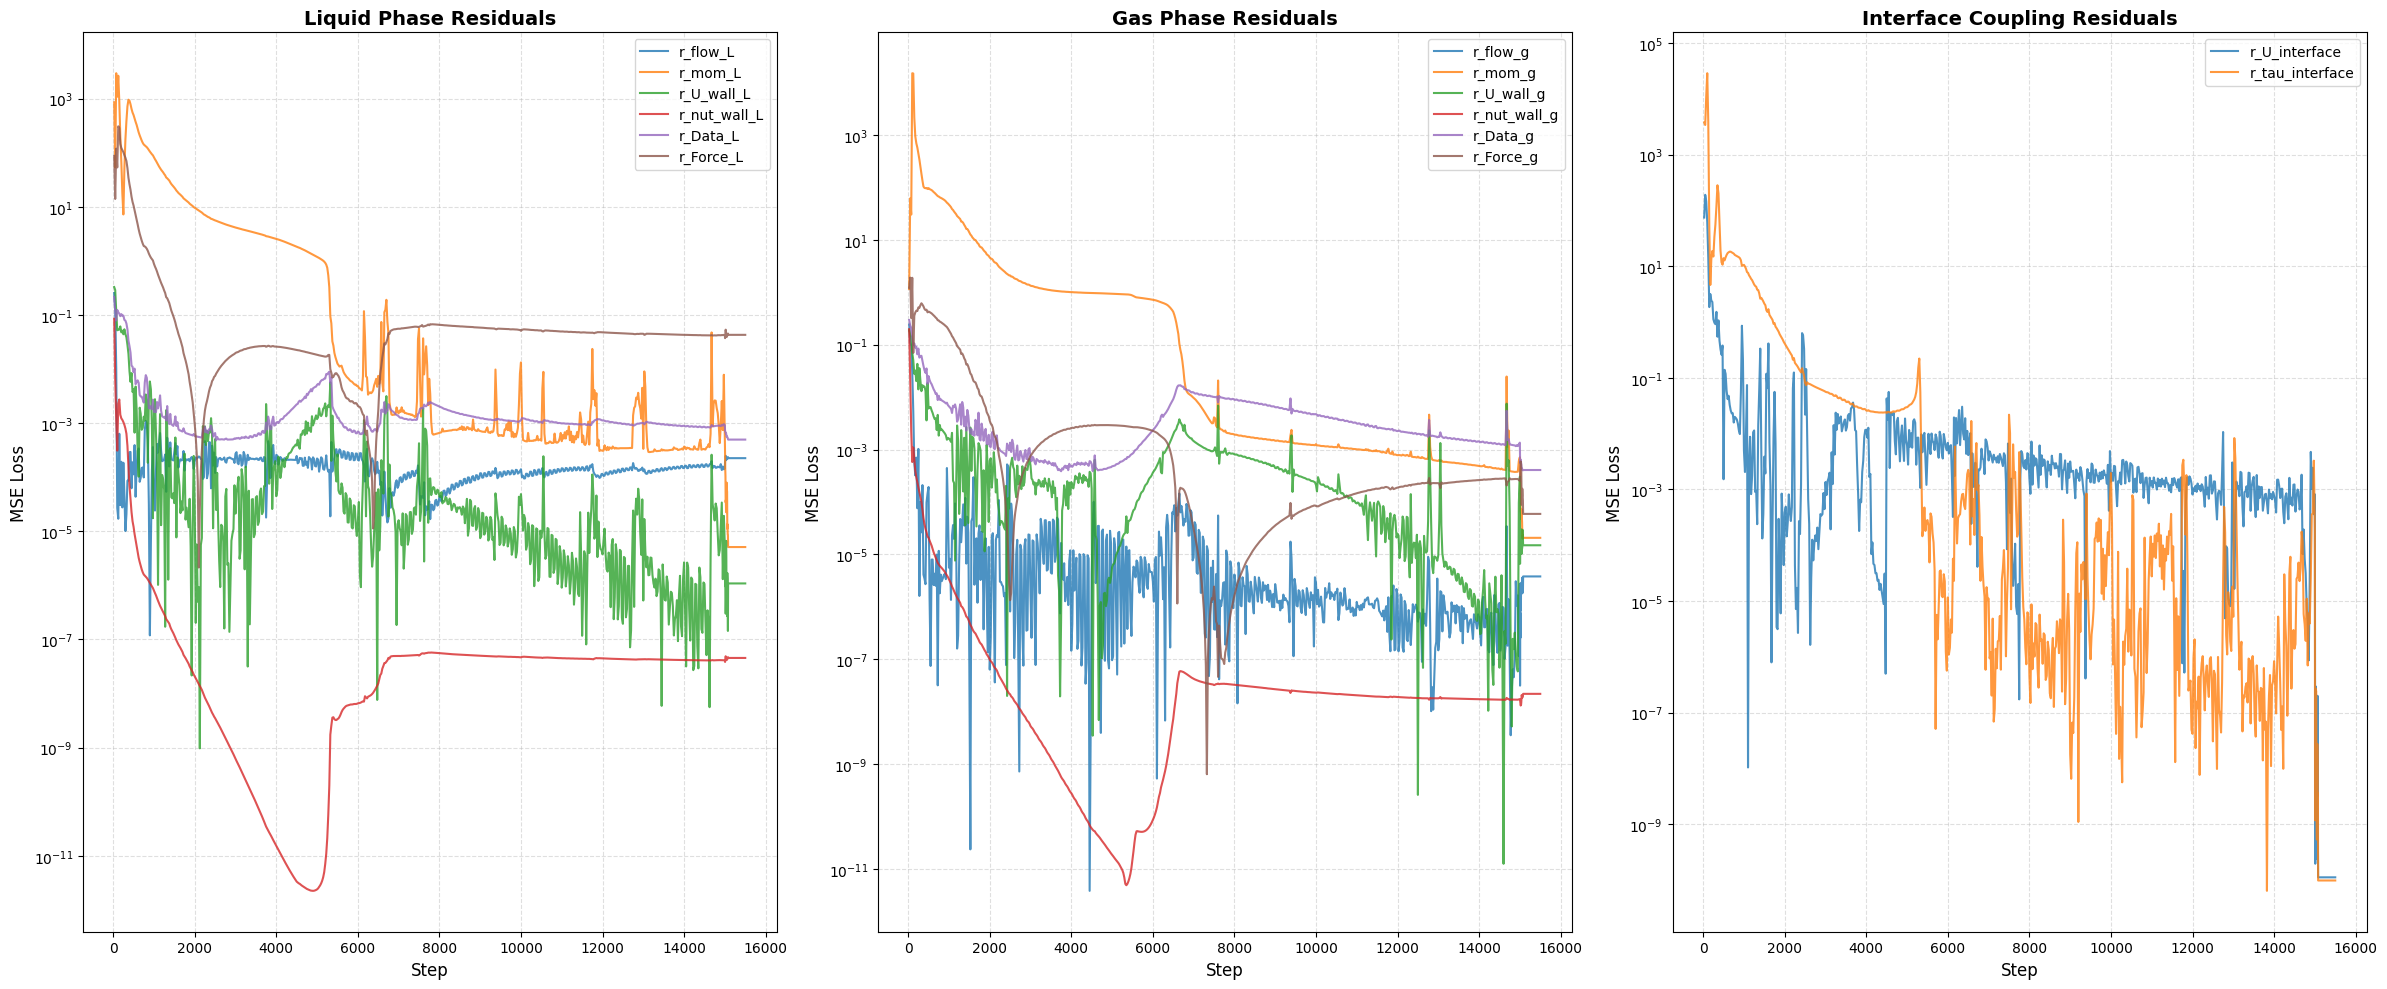

[LBFGS 500] Loss: 1.173e+00


In [ ]:
# @title Training Loop RANS

from torch.optim import Adam, LBFGS
import os
import torch
from torch.optim.lr_scheduler import StepLR
from google.colab import drive
import matplotlib.pyplot as plt
from IPython import display as ipd
drive.mount('/content/drive')

# --- Initialize the Models with Xavier Weights ---
model_Liquid.apply(init_weights_xavier)
model_Gas.apply(init_weights_xavier)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_Liquid.to(device)
model_Gas.to(device)

# --- Learanable Parameters ---
all_model_params = (list(model_Liquid.parameters()) +
                    list(model_Gas.parameters()))

# --- Name of Residuals ---
RESIDUAL_NAMES = ['r_flow_L', 'r_mom_L', 'r_U_wall_L', 'r_nut_wall_L', 'r_Data_L', 'r_Force_L',
                  'r_flow_g', 'r_mom_g', 'r_U_wall_g', 'r_nut_wall_g', 'r_Data_g', 'r_Force_g',
                  'r_U_interface', 'r_tau_interface']

num_tasks = len(RESIDUAL_NAMES)

# --- Initial and Final Weights ---
fixed_weights = torch.tensor([1000.0, 1e-3, 1000.0, 1000.0, 1000.0, 0.0,
                              1000.0, 1e-3, 1000.0, 1000.0, 1000.0, 0.0,
                              1.0, 1e-3]).to(device)

fixed_weights_final = torch.tensor([1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 0.0,
                                    1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 0.0,
                                    1000.0, 1000.0]).to(device)

# --- Make the Required Torch Tensors ---
R_L_train   = torch.tensor(R_L[i_LG], dtype=torch.float32).to(device)
R_g_train   = torch.tensor(R_g[i_LG], dtype=torch.float32).to(device)
Y_I_L_train = torch.tensor(Y_I_L[i_LG], dtype=torch.float32).to(device)
Y_I_g_train = torch.tensor(Y_I_g[i_LG], dtype=torch.float32).to(device)
m_tau_wall_L_train = torch.tensor(m_tau_wall_L[i_LG], dtype=torch.float32).to(device)
m_tau_wall_g_train = torch.tensor(m_tau_wall_g[i_LG], dtype=torch.float32).to(device)
Re_L_train = torch.tensor(Re_L[i_LG], dtype=torch.float32).to(device)
Re_g_train = torch.tensor(Re_g[i_LG], dtype=torch.float32).to(device)
Vel_ave_L_train = torch.tensor(Vel_ave_L[i_LG], dtype=torch.float32).to(device)
Vel_ave_g_train = torch.tensor(Vel_ave_g[i_LG], dtype=torch.float32).to(device)
rho_L_train = torch.tensor(rho_L, dtype=torch.float32).to(device)
rho_g_train = torch.tensor(rho_g, dtype=torch.float32).to(device)
dPdX_L_train = torch.tensor(dPdX_L[i_LG], dtype=torch.float32).to(device)
dPdX_g_train = torch.tensor(dPdX_g[i_LG], dtype=torch.float32).to(device)
U_Data_L_train = torch.tensor(U_Data_L, dtype=torch.float32).to(device)
U_Data_g_train = torch.tensor(U_Data_g, dtype=torch.float32).to(device)
Y_Data_L_train = torch.tensor(Y_Data_L, dtype=torch.float32).to(device)
Y_Data_g_train = torch.tensor(Y_Data_g, dtype=torch.float32).to(device)
Y_c_L_train = torch.tensor(Y_c_L, dtype=torch.float32).to(device)
Y_c_g_train = torch.tensor(Y_c_g, dtype=torch.float32).to(device)

# --- Optimizers ---
max_steps = 15000
max_lbfgs_steps = 500
PRINT_EVERY = 25
SAVE_EVERY  = 7500
CKPT_DIR = '/content/drive/MyDrive/StratifiedWeights'
os.makedirs(CKPT_DIR, exist_ok=True)

opt_adam = Adam(all_model_params, lr=1e-3)
scheduler = StepLR(opt_adam, step_size=1500, gamma=0.85)

step_history, raw_total_history, res_history = [], [], []

# ------------------------------------------------------------------------------
# STAGE 1: Adam Optimization
# ------------------------------------------------------------------------------
print("Starting Stage 1: Adam...")
for step in range(1, max_steps + 1):
    model_Liquid.train()
    model_Gas.train()
    opt_adam.zero_grad(set_to_none=True)

    # 1. Compute Residuals
    res_tuple = compute_residuals_total(model_Liquid, model_Gas,
                                        R_L_train, R_g_train,
                                        Y_I_L_train, Y_I_g_train,
                                        m_tau_wall_L_train, m_tau_wall_g_train,
                                        Re_L_train, Re_g_train,
                                        Vel_ave_L_train, Vel_ave_g_train,
                                        rho_L_train, rho_g_train,
                                        dPdX_L_train, dPdX_g_train,
                                        U_Data_L_train, U_Data_g_train,
                                        Y_c_L_train, Y_c_g_train,
                                        Y_Data_L_train, Y_Data_g_train)

    # 2. Weighted Loss
    w_a = min(1000000**(2*step/max_steps), 1000000)
    w_b = min(1000**(2*step/max_steps), 1000)
    updating_weights = torch.tensor([1.0, w_a, 1.0, 1.0, 1.0, 0.0,
                                     1.0, w_a, 1.0, 1.0, 1.0, 0.0,
                                     w_b, w_a]).to(device)

    res_stack = torch.stack(res_tuple)
    total_loss = torch.sum(fixed_weights * updating_weights * res_stack)

    # 3. Backprop
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(all_model_params, 1.0)
    opt_adam.step()
    scheduler.step()

    # 4. Logging
    if step % PRINT_EVERY == 0:
        with torch.no_grad():
            raw_vals = [r.item() for r in res_tuple]
            step_history.append(step)
            raw_total_history.append(sum(raw_vals))
            res_history.append(raw_vals)
            plot_training_progress(step_history, raw_total_history, res_history, RESIDUAL_NAMES)
            print(f"[ADAM {step}] Loss: {raw_vals}")

    if step % SAVE_EVERY == 0:
      ckpt = {
            'step': step,
            'model_liquid': model_Liquid.state_dict(),
            'model_gas': model_Gas.state_dict()
            }
      torch.save(ckpt, os.path.join(CKPT_DIR, f"{i_LG}_Step_Taylor_{step:05d}.pt"))

# ------------------------------------------------------------------------------
# STAGE 2: LBFGS Optimization
# ------------------------------------------------------------------------------
print("\nStarting Stage 2: LBFGS...")
opt_lbfgs = LBFGS(
    all_model_params, lr=1, max_iter=20, history_size=50, line_search_fn="strong_wolfe"
)

def closure():
    opt_lbfgs.zero_grad()
    res_t = compute_residuals_total(model_Liquid, model_Gas,
                                        R_L_train, R_g_train,
                                        Y_I_L_train, Y_I_g_train,
                                        m_tau_wall_L_train, m_tau_wall_g_train,
                                        Re_L_train, Re_g_train,
                                        Vel_ave_L_train, Vel_ave_g_train,
                                        rho_L_train, rho_g_train,
                                        dPdX_L_train, dPdX_g_train,
                                        U_Data_L_train, U_Data_g_train,
                                        Y_c_L_train, Y_c_g_train,
                                        Y_Data_L_train, Y_Data_g_train)


    loss = torch.sum(fixed_weights_final * torch.stack(res_t))
    loss.backward()
    return loss

for l_step in range(1, max_lbfgs_steps + 1):
    current_loss = opt_lbfgs.step(closure)

    if l_step % 5 == 0:
        res_t = compute_residuals_total(model_Liquid, model_Gas,
                                        R_L_train, R_g_train,
                                        Y_I_L_train, Y_I_g_train,
                                        m_tau_wall_L_train, m_tau_wall_g_train,
                                        Re_L_train, Re_g_train,
                                        Vel_ave_L_train, Vel_ave_g_train,
                                        rho_L_train, rho_g_train,
                                        dPdX_L_train, dPdX_g_train,
                                        U_Data_L_train, U_Data_g_train,
                                        Y_c_L_train, Y_c_g_train,
                                        Y_Data_L_train, Y_Data_g_train)


        raw_vals = [r.item() for r in res_t]
        step_history.append(max_steps + l_step)
        raw_total_history.append(sum(raw_vals))
        res_history.append(raw_vals)
        plot_training_progress(step_history, raw_total_history, res_history, RESIDUAL_NAMES)
        print(f"[LBFGS {l_step}] Loss: {current_loss.item():.3e}")

ckpt = {'model_liquid': model_Liquid.state_dict(),
        'model_gas': model_Gas.state_dict()}

torch.save(ckpt, os.path.join(CKPT_DIR, f"{i_LG}_Final_Taylor.pt"))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded checkpoint from step N/A


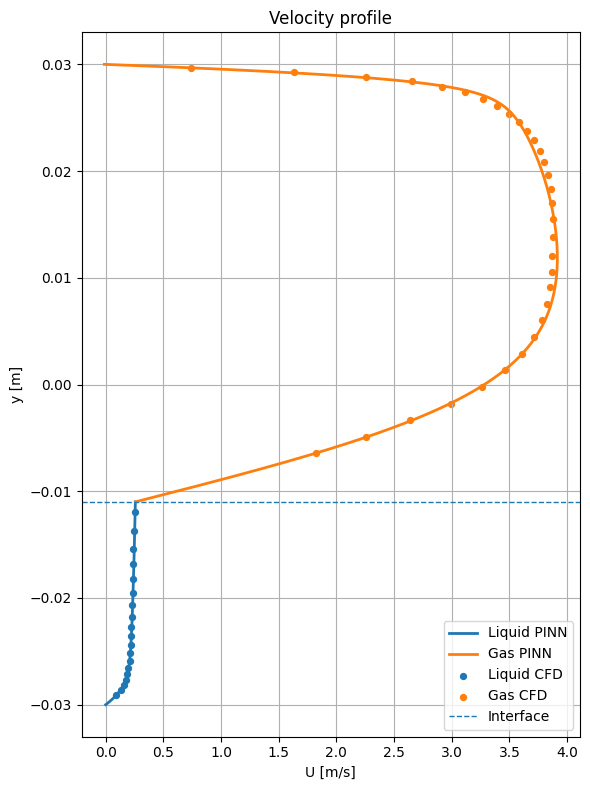

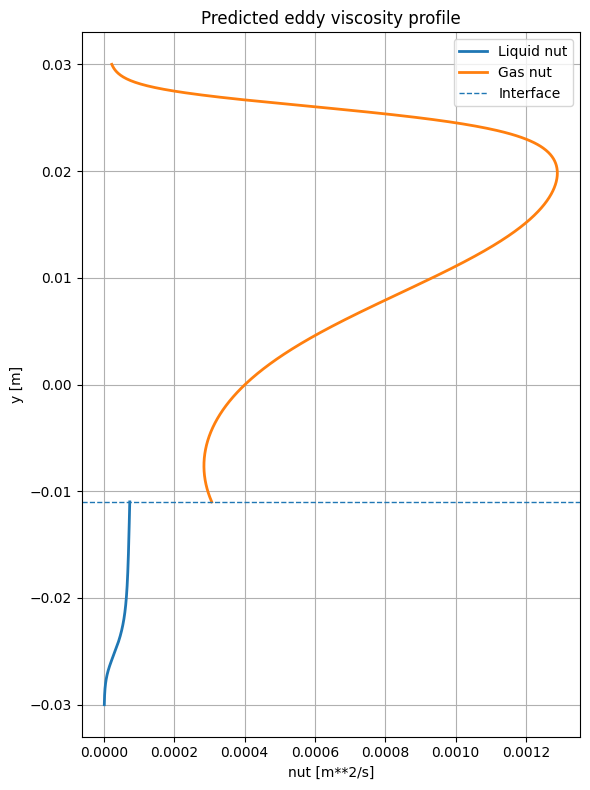

In [ ]:
# @title Plot Velocity and nut Profiles - 1D inverse model

import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

################################################################################
# 1) Load models
################################################################################

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_Liquid.to(device)
model_Gas.to(device)

CKPT_DIR  = '/content/drive/MyDrive/StratifiedWeights'
ckpt_path = os.path.join(CKPT_DIR, f"{i_LG}_Final_Taylor.pt")

if not os.path.isfile(ckpt_path):
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

ckpt = torch.load(ckpt_path, map_location=device)

model_Liquid.load_state_dict(ckpt['model_liquid'])
model_Gas.load_state_dict(ckpt['model_gas'])

model_Liquid.eval()
model_Gas.eval()

print(f"Loaded checkpoint from step {ckpt.get('step', 'N/A')}")

################################################################################
# 2) Build 1D y-grids
################################################################################
# These Y coordinates are assumed to be in the same nondimensional coordinate
# system used during training.

Y_L = np.linspace(-R_L[i_LG], Y_I_L[i_LG], 1000).reshape(-1, 1)
Y_g = np.linspace( Y_I_g[i_LG], R_g[i_LG], 1000).reshape(-1, 1)

Y_L_t = torch.tensor(Y_L, dtype=torch.float32, device=device)
Y_g_t = torch.tensor(Y_g, dtype=torch.float32, device=device)

################################################################################
# 3) Predict U and nut
################################################################################
with torch.no_grad():
    out_L = model_Liquid(Y_L_t)
    out_g = model_Gas(Y_g_t)

U_L = out_L[:, 0:1]
U_g = out_g[:, 0:1]

nut_L = F.softplus(out_L[:, 1:2])
nut_g = F.softplus(out_g[:, 1:2])

################################################################################
# 4) Convert to dimensional velocity and physical y
################################################################################
# Here I keep the same convention you used before:
# y_physical = Dh * Y
# U_physical = Vel_ave * U

U_L_dim = (Vel_ave_L[i_LG] * U_L).cpu().numpy().squeeze()
U_g_dim = (Vel_ave_g[i_LG] * U_g).cpu().numpy().squeeze()

y_L = (Dh_L[i_LG] * Y_L_t).cpu().numpy().squeeze()
y_g = (Dh_g[i_LG] * Y_g_t).cpu().numpy().squeeze()

nut_L_np = nut_L.cpu().numpy().squeeze()
nut_g_np = nut_g.cpu().numpy().squeeze()

nut_L_dim = nut_L_np*Vel_ave_L[i_LG]*Dh_L[i_LG]
nut_g_dim = nut_g_np*Vel_ave_g[i_LG]*Dh_g[i_LG]
################################################################################
# 5) Interface location
################################################################################
y_I_dim = y_I[i_LG]

################################################################################
# 6) Plot velocity profile
################################################################################
plt.figure(figsize=(6, 8))

plt.plot(U_L_dim, y_L, label='Liquid PINN', linewidth=2)
plt.plot(U_g_dim, y_g, label='Gas PINN', linewidth=2)

plt.scatter(U_Data_L*Vel_ave_L[i_LG], Y_Data_L*Dh_L[i_LG], s=18, label='Liquid CFD')
plt.scatter(U_Data_g*Vel_ave_g[i_LG], Y_Data_g*Dh_g[i_LG], s=18, label='Gas CFD')

plt.axhline(y=y_I_dim, linestyle='--', linewidth=1, label='Interface')

plt.xlabel("U [m/s]")
plt.ylabel("y [m]")
plt.title("Velocity profile")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

################################################################################
# 7) Plot eddy viscosity profile
################################################################################
plt.figure(figsize=(6, 8))

plt.plot(nut_L_dim, y_L, label='Liquid nut', linewidth=2)
plt.plot(nut_g_dim, y_g, label='Gas nut', linewidth=2)

plt.axhline(y=y_I_dim, linestyle='--', linewidth=1, label='Interface')

plt.xlabel("nut [m**2/s]")
plt.ylabel("y [m]")
plt.title("Predicted eddy viscosity profile")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# --- Make the Required Torch Tensors ---
R_L_train   = torch.tensor(R_L[i_LG], dtype=torch.float32).to(device)
R_g_train   = torch.tensor(R_g[i_LG], dtype=torch.float32).to(device)
Y_I_L_train = torch.tensor(Y_I_L[i_LG], dtype=torch.float32).to(device)
Y_I_g_train = torch.tensor(Y_I_g[i_LG], dtype=torch.float32).to(device)
m_tau_wall_L_train = torch.tensor(m_tau_wall_L[i_LG], dtype=torch.float32).to(device)
m_tau_wall_g_train = torch.tensor(m_tau_wall_g[i_LG], dtype=torch.float32).to(device)
Re_L_train = torch.tensor(Re_L[i_LG], dtype=torch.float32).to(device)
Re_g_train = torch.tensor(Re_g[i_LG], dtype=torch.float32).to(device)
Vel_ave_L_train = torch.tensor(Vel_ave_L[i_LG], dtype=torch.float32).to(device)
Vel_ave_g_train = torch.tensor(Vel_ave_g[i_LG], dtype=torch.float32).to(device)
rho_L_train = torch.tensor(rho_L, dtype=torch.float32).to(device)
rho_g_train = torch.tensor(rho_g, dtype=torch.float32).to(device)
dPdX_L_train = torch.tensor(dPdX_L[i_LG], dtype=torch.float32).to(device)
dPdX_g_train = torch.tensor(dPdX_g[i_LG], dtype=torch.float32).to(device)
U_Data_L_train = torch.tensor(U_Data_L, dtype=torch.float32).to(device)
U_Data_g_train = torch.tensor(U_Data_g, dtype=torch.float32).to(device)
Y_Data_L_train = torch.tensor(Y_Data_L, dtype=torch.float32).to(device)
Y_Data_g_train = torch.tensor(Y_Data_g, dtype=torch.float32).to(device)
Y_c_L_train = torch.tensor(Y_c_L, dtype=torch.float32).to(device)
Y_c_g_train = torch.tensor(Y_c_g, dtype=torch.float32).to(device)
Dh_L_train = torch.tensor(Dh_L[i_LG], dtype=torch.float32).to(device)
Dh_g_train = torch.tensor(Dh_g[i_LG], dtype=torch.float32).to(device)


In [ ]:
# @title Post-Process - 1D inverse model

import torch
import torch.nn.functional as F

################################################################################
# 1) Wall friction factor
################################################################################
def compute_f_Wall_1D(model, phase, Y_wall, Re):
    """
    Computes wall shear and Fanning friction factor from the 1D model.

    Inputs
    ------
    model   : neural network with output [U, nut_raw]
    phase   : 'L' or 'g'
    Y_wall  : scalar wall location in the model coordinate
    Re      : Reynolds number used in the nondimensional PDE

    Returns
    -------
    tau_wall : nondimensional wall shear stress
    f_wall   : nondimensional Fanning friction factor
    """

    Y_wall_t = torch.tensor([[Y_wall]], dtype=torch.float32, device=device, requires_grad=True)

    out = model(Y_wall_t)
    U = out[:, 0:1]

    U_Y = torch.autograd.grad(U, Y_wall_t,
                              grad_outputs=torch.ones_like(U),
                              create_graph=False)[0]

    # At the wall, only molecular viscosity contributes if nut -> 0 is enforced.
    if phase == 'L':
        tau_wall = U_Y / Re
    elif phase == 'g':
        tau_wall = -U_Y / Re
    else:
        raise ValueError("phase must be 'L' or 'g'")

    f_wall = 2.0 * tau_wall

    return tau_wall.detach(), f_wall.detach()

################################################################################
# 2) Interface shear stress
################################################################################
def compute_tau_Interface_1D(model, phase, Y_interface, Re):
    """
    Computes nondimensional interface shear stress from the 1D model.

    Inputs
    ------
    model       : neural network with output [U, nut_raw]
    phase       : 'L' or 'g'
    Y_interface : scalar interface location
    Re          : Reynolds number

    Returns
    -------
    tau_interface : nondimensional interface shear stress
    """

    Y_int_t = torch.tensor([[Y_interface]], dtype=torch.float32, device=device, requires_grad=True)

    out = model(Y_int_t)
    U = out[:, 0:1]
    nut = F.softplus(out[:, 1:2])

    U_Y = torch.autograd.grad(U, Y_int_t,
                              grad_outputs=torch.ones_like(U),
                              create_graph=False)[0]

    nu_eff = 1.0 / Re + nut

    if phase == 'L':
        tau_interface = -nu_eff * U_Y
    elif phase == 'g':
        tau_interface =  nu_eff * U_Y
    else:
        raise ValueError("phase must be 'L' or 'g'")

    return tau_interface.detach()

################################################################################
# 3) Pressure-gradient prediction from PDE RHS
################################################################################
def compute_dPdX_from_PDE_1D(model, Y_c, Re):
    """
    Computes an effective predicted dP/dX from the mean PDE RHS:
        dP/dX ~= mean( d/dY[(1/Re + nut) dU/dY] )

    Inputs
    ------
    model : neural network with output [U, nut_raw]
    Y_c   : collocation points tensor of shape [N,1]
    Re    : Reynolds number

    Returns
    -------
    dPdX_pred : scalar tensor
    """

    Y_c = Y_c.clone().detach().requires_grad_(True)

    out = model(Y_c)
    U = out[:, 0:1]
    nut = F.softplus(out[:, 1:2])

    U_Y = torch.autograd.grad(U, Y_c,
                              grad_outputs=torch.ones_like(U),
                              create_graph=True)[0]

    nu_eff = 1.0 / Re + nut
    Flux = nu_eff * U_Y

    Diff = torch.autograd.grad(Flux, Y_c,
                               grad_outputs=torch.ones_like(Flux),
                               create_graph=False)[0]

    dPdX_pred = Diff.mean()

    return dPdX_pred.detach()

################################################################################
# 4) Optional: momentum residual for post-processing
################################################################################
def compute_residuals_Momentum_1D(model, Y_c, Re, dPdX):
    """
    Computes 1D flow and momentum residuals for diagnostics.
    """

    Y_c = Y_c.clone().detach().requires_grad_(True)

    out = model(Y_c)
    U = out[:, 0:1]
    nut = F.softplus(out[:, 1:2])

    U_Y = torch.autograd.grad(U, Y_c,
                              grad_outputs=torch.ones_like(U),
                              create_graph=True)[0]

    nu_eff = 1.0 / Re + nut
    Flux = nu_eff * U_Y

    Diff = torch.autograd.grad(Flux, Y_c,
                               grad_outputs=torch.ones_like(Flux),
                               create_graph=True)[0]

    r_flow = (U.mean() - 1.0)**2
    r_mom = torch.mean(((dPdX - Diff) / (torch.abs(dPdX) + 1e-9))**2)

    return r_flow.detach(), r_mom.detach(), Diff.mean().detach()

################################################################################
# 5) Run post-processing
################################################################################

# Wall quantities
tau_wall_L_predic, f_wall_L_predic = compute_f_Wall_1D(
    model_Liquid, 'L', -R_L_train, Re_L_train
)

tau_wall_g_predic, f_wall_g_predic = compute_f_Wall_1D(
    model_Gas, 'g', R_g_train, Re_g_train
)

# Interface quantities
tau_interface_L_predic = compute_tau_Interface_1D(
    model_Liquid, 'L', Y_I_L_train, Re_L_train
)

tau_interface_g_predic = compute_tau_Interface_1D(
    model_Gas, 'g', Y_I_g_train, Re_g_train
)

# Pressure gradient from PDE
dPdX_L_predic = compute_dPdX_from_PDE_1D(
    model_Liquid, Y_c_L_train, Re_L_train
)

dPdX_g_predic = compute_dPdX_from_PDE_1D(
    model_Gas, Y_c_g_train, Re_g_train
)

# Residual diagnostics
r_flow_L_diag, r_mom_L_diag, _ = compute_residuals_Momentum_1D(
    model_Liquid, Y_c_L_train, Re_L_train, dPdX_L_train
)

r_flow_g_diag, r_mom_g_diag, _ = compute_residuals_Momentum_1D(
    model_Gas, Y_c_g_train, Re_g_train, dPdX_g_train
)

################################################################################
# 6) Print results
################################################################################

print(f"f_wall_L_predic: {f_wall_L_predic.item():.6f}; f_wall_L_target: {f_wall_L[i_LG]:.6f}")
print(f"f_wall_g_predic: {f_wall_g_predic.item():.6f}; f_wall_g_target: {f_wall_g[i_LG]:.6f}\n")

print(f"tau_wall_L_predic [dim]: {(tau_wall_L_predic * rho_L_train * Vel_ave_L_train**2).item():.6f}")
print(f"tau_wall_g_predic [dim]: {(tau_wall_g_predic * rho_g_train * Vel_ave_g_train**2).item():.6f}\n")

print(f"tau_interface_L_predic [dim]: {(tau_interface_L_predic * rho_L_train * Vel_ave_L_train**2).item():.6f}")
print(f"tau_interface_g_predic [dim]: {(tau_interface_g_predic * rho_g_train * Vel_ave_g_train**2).item():.6f}")
print(f"tau_interface_target [dim]: {tau_interface[i_LG]:.6f}\n")

print(f"f_interface_L_predic : {(2*tau_interface_L_predic*rho_L_train*Vel_ave_L_train**2/(rho_g_train*(Vel_ave_g_train-Vel_ave_L_train)**2)).item():.6f}")
print(f"f_interface_g_predic : {(2*tau_interface_g_predic*rho_g_train*Vel_ave_g_train**2/(rho_g_train*(Vel_ave_g_train-Vel_ave_L_train)**2)).item():.6f}\n")

print(f"dPdX_L_predic: {dPdX_L_predic.item():.6f}; dPdX_L_target: {float(dPdX_L_train):.6f}")
print(f"dPdX_g_predic: {dPdX_g_predic.item():.6f}; dPdX_g_target: {float(dPdX_g_train):.6f}\n")

print(f"r_flow_L_diag: {r_flow_L_diag.item():.6e}")
print(f"r_mom_L_diag : {r_mom_L_diag.item():.6e}")
print(f"r_flow_g_diag: {r_flow_g_diag.item():.6e}")
print(f"r_mom_g_diag : {r_mom_g_diag.item():.6e}")

f_wall_L_predic: 0.004935; f_wall_L_target: 0.005372
f_wall_g_predic: 0.007349; f_wall_g_target: 0.011244

tau_wall_L_predic [dim]: 0.119862
tau_wall_g_predic [dim]: 0.044239

tau_interface_L_predic [dim]: -0.139507
tau_interface_g_predic [dim]: 0.139508
tau_interface_target [dim]: 0.083527

f_interface_L_predic : -0.026772
f_interface_g_predic : 0.026772

dPdX_L_predic: -0.003031; dPdX_L_target: -0.003031
dPdX_g_predic: -0.024189; dPdX_g_target: -0.024189

r_flow_L_diag: 2.245438e-04
r_mom_L_diag : 5.100770e-06
r_flow_g_diag: 3.811671e-06
r_mom_g_diag : 2.075242e-05


In [ ]:
# 1. Compute Errors
error_tuple = compute_residuals_total(model_Liquid, model_Gas,
                                    R_L_train, R_g_train,
                                    Y_I_L_train, Y_I_g_train,
                                    m_tau_wall_L_train, m_tau_wall_g_train,
                                    Re_L_train, Re_g_train,
                                    Vel_ave_L_train, Vel_ave_g_train,
                                    rho_L_train, rho_g_train,
                                    dPdX_L_train, dPdX_g_train,
                                    U_Data_L_train, U_Data_g_train,
                                    Y_c_L_train, Y_c_g_train,
                                    Y_Data_L_train, Y_Data_g_train)

# r_flow_L, r_mom_L, r_U_wall_L, r_nut_wall_L, r_Data_L, r_Force_L,
# r_flow_g, r_mom_g, r_U_wall_g, r_nut_wall_g, r_Data_g, r_Force_g,
# r_U_interface, r_tau_interface
error_names = [
    "r_flow_L", "r_mom_L", "r_U_wall_L", "r_nut_wall_L", "r_Data_L", "r_Force_L",
    "r_flow_g", "r_mom_g", "r_U_wall_g", "r_nut_wall_g", "r_Data_g", "r_Force_g",
    "r_U_interface", "r_tau_interface"
]

for name, value in zip(error_names, error_tuple):
    print(f"{name:20s}: {torch.sqrt(value):.2e}")

r_flow_L            : 1.50e-02
r_mom_L             : 2.26e-03
r_U_wall_L          : 1.04e-03
r_nut_wall_L        : 2.13e-04
r_Data_L            : 2.22e-02
r_Force_L           : 2.07e-01
r_flow_g            : 1.95e-03
r_mom_g             : 4.56e-03
r_U_wall_g          : 3.87e-03
r_nut_wall_g        : 1.48e-04
r_Data_g            : 2.02e-02
r_Force_g           : 7.70e-03
r_U_interface       : 1.18e-05
r_tau_interface     : 9.91e-06


In [ ]:
# @title Build Liquid/Gas datasets: normalized distances + nut/nut_p + delta

from google.colab import drive
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
drive.mount('/content/drive')

# ============================================================
# Settings
# ============================================================
CKPT_DIR = '/content/drive/MyDrive/StratifiedWeights'
N_POINTS_PER_CASE = 200

OUT_LIQUID_CSV = '/content/drive/MyDrive/liquid_dataset_geometry_nut_norm.csv'
OUT_GAS_CSV    = '/content/drive/MyDrive/gas_dataset_geometry_nut_norm.csv'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_Liquid.to(device)
model_Gas.to(device)

# ============================================================
# Helper: evaluate nut profile
# ============================================================
def get_nut_profile(model, Y):
    Y = Y.clone().detach()
    with torch.no_grad():
        out = model(Y)
        nut = F.softplus(out[:, 1:2])
    return nut.detach()

# ============================================================
# Helper: build phase dataset rows
# ============================================================
def build_phase_rows(phase, case_id, Y, nut, Y_I, R):
    """
    phase = 'L' for liquid or 'g' for gas

    Output columns:
        delta
        d_wall_delta
        d_interface_delta
        d_wall_p_delta
        d_interface_p_delta
        nut_interface
        nut_p
        nut
        nut_over_nut_p
    """
    Y_np = Y.detach().cpu().numpy().squeeze()
    nut_np = nut.detach().cpu().numpy().squeeze()

    # nut at interface
    idx_I = np.argmin(np.abs(Y_np - Y_I))
    nut_interface = nut_np[idx_I]

    # peak location and value for THIS phase and THIS case
    idx_p = np.argmax(nut_np)
    Y_p = Y_np[idx_p]
    nut_p = nut_np[idx_p]

    eps = 1e-12
    rows = []

    if phase == 'g':
        delta = R - Y_I
        d_wall_p = R - Y_p
        d_interface_p = Y_p - Y_I

        for j in range(len(Y_np)):
            Yj = Y_np[j]
            nutj = nut_np[j]

            d_wall = R - Yj
            d_interface = Yj - Y_I

            rows.append({
                'case_id': case_id,
                'Y': Yj,
                'Y_p': Y_p,
                'delta': delta,
                'd_wall_delta': d_wall / delta,
                'd_interface_delta': d_interface / delta,
                'd_wall_p_delta': d_wall_p / delta,
                'd_interface_p_delta': d_interface_p / delta,
                'nut_interface': nut_interface,
                'nut_p': nut_p,
                'nut': nutj,
                'nut_over_nut_p': nutj / (nut_p + eps),
            })

    elif phase == 'L':
        # liquid wall is at Y = -R
        delta = Y_I - (-R)       # = Y_I + R
        d_wall_p = Y_p - (-R)    # = Y_p + R
        d_interface_p = Y_I - Y_p

        for j in range(len(Y_np)):
            Yj = Y_np[j]
            nutj = nut_np[j]

            d_wall = Yj - (-R)   # = Y + R
            d_interface = Y_I - Yj

            rows.append({
                'case_id': case_id,
                'Y': Yj,
                'Y_p': Y_p,
                'delta': delta,
                'd_wall_delta': d_wall / delta,
                'd_interface_delta': d_interface / delta,
                'd_wall_p_delta': d_wall_p / delta,
                'd_interface_p_delta': d_interface_p / delta,
                'nut_interface': nut_interface,
                'nut_p': nut_p,
                'nut': nutj,
                'nut_over_nut_p': nutj / (nut_p + eps),
            })

    else:
        raise ValueError("phase must be 'L' or 'g'")

    return rows

# ============================================================
# Collect datasets
# ============================================================
rows_liquid = []
rows_gas = []

for i_LG in range(8):
    print(f'Processing case {i_LG} ...')

    # --------------------------------------------------------
    # load checkpoint
    # --------------------------------------------------------
    ckpt_path = os.path.join(CKPT_DIR, f"{i_LG}_Final_Taylor.pt")

    if not os.path.isfile(ckpt_path):
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

    ckpt = torch.load(ckpt_path, map_location=device)

    model_Liquid.load_state_dict(ckpt['model_liquid'])
    model_Gas.load_state_dict(ckpt['model_gas'])

    model_Liquid.to(device).eval()
    model_Gas.to(device).eval()

    # --------------------------------------------------------
    # sample Y points
    # --------------------------------------------------------
    Y_L = torch.linspace(
        -float(R_L[i_LG]),
        float(Y_I_L[i_LG]),
        N_POINTS_PER_CASE,
        device=device
    ).view(-1, 1)

    Y_g = torch.linspace(
        float(Y_I_g[i_LG]),
        float(R_g[i_LG]),
        N_POINTS_PER_CASE,
        device=device
    ).view(-1, 1)

    # --------------------------------------------------------
    # liquid
    # --------------------------------------------------------
    nut_L = get_nut_profile(model_Liquid, Y_L)

    rows_liquid.extend(
        build_phase_rows(
            phase='L',
            case_id=i_LG,
            Y=Y_L,
            nut=nut_L,
            Y_I=float(Y_I_L[i_LG]),
            R=float(R_L[i_LG]),
        )
    )

    # --------------------------------------------------------
    # gas
    # --------------------------------------------------------
    nut_g = get_nut_profile(model_Gas, Y_g)

    rows_gas.extend(
        build_phase_rows(
            phase='g',
            case_id=i_LG,
            Y=Y_g,
            nut=nut_g,
            Y_I=float(Y_I_g[i_LG]),
            R=float(R_g[i_LG]),
        )
    )

# ============================================================
# Save
# ============================================================
df_liquid = pd.DataFrame(rows_liquid)
df_gas = pd.DataFrame(rows_gas)

df_liquid.to_csv(OUT_LIQUID_CSV, index=False)
df_gas.to_csv(OUT_GAS_CSV, index=False)

print("\nDone.")
print(f"Liquid dataset saved to: {OUT_LIQUID_CSV}")
print(f"Gas dataset saved to   : {OUT_GAS_CSV}")

print("\nLiquid head:")
print(df_liquid.head())

print("\nGas head:")
print(df_gas.head())

Mounted at /content/drive
Processing case 0 ...
Processing case 1 ...
Processing case 2 ...
Processing case 3 ...
Processing case 4 ...
Processing case 5 ...
Processing case 6 ...
Processing case 7 ...

Done.
Liquid dataset saved to: /content/drive/MyDrive/liquid_dataset_geometry_nut_norm.csv
Gas dataset saved to   : /content/drive/MyDrive/gas_dataset_geometry_nut_norm.csv

Liquid head:
   case_id         Y       Y_p     delta  d_wall_delta  d_interface_delta  \
0        0 -1.176829 -0.385991  0.790837      0.000000           1.000000   
1        0 -1.172854 -0.385991  0.790837      0.005025           0.994975   
2        0 -1.168880 -0.385991  0.790837      0.010050           0.989950   
3        0 -1.164906 -0.385991  0.790837      0.015075           0.984925   
4        0 -1.160932 -0.385991  0.790837      0.020100           0.979900   

   d_wall_p_delta  d_interface_p_delta  nut_interface     nut_p           nut  \
0             1.0                  0.0       0.013887  0.013887  5